In [23]:
import torch
import matplotlib.pyplot as plt
from torch import nn, Tensor
from sklearn.datasets import make_moons
from sklearn.datasets import make_swiss_roll

from flow_matching.solver import ODESolver 
from flow_matching.utils import ModelWrapper 

In [24]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: cuda


In [25]:
class FlowModel(nn.Module):
    def __init__(self, dim=2, h=256):
        super().__init__()
        # self.net = nn.Sequential(
        #     nn.Linear(dim + 1, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, h),
        #     nn.SiLU(),
        #     nn.Linear(h, dim)
        # )

        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim))
    
    def forward(self, x: Tensor, t: Tensor) -> Tensor:
        t = t.expand(*x.shape[:-1], 1) if t.dim() == 0 else t.view(-1, 1).expand(*x.shape[:-1], -1)
        return self.net(torch.cat((t, x), dim=-1))

velocity_model = FlowModel()
velocity_model.to(device)


FlowModel(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=256, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=256, out_features=2, bias=True)
  )
)

#### Dataset

Data shape: (5000, 2)


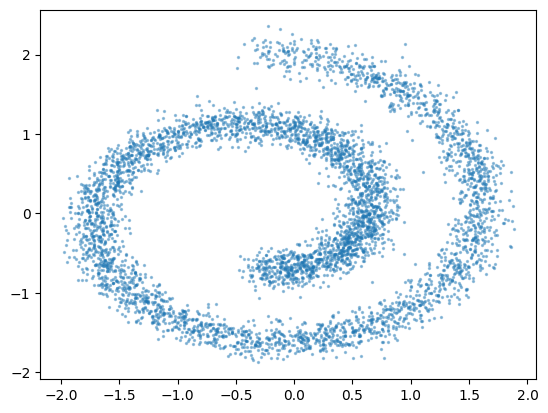

In [26]:
def get_data_batch(batch_size: int, noise: float = 0.8) -> Tensor:
    return Tensor(make_swiss_roll(batch_size, noise=noise)[0][:, [0, 2]])

X = get_data_batch(5000)
X = (X - X.mean(dim=0)) / X.std(dim=0)
X = X.numpy()
plt.scatter(X[:, 0], X[:, 1], s=2, alpha=0.4)

print("Data shape:", X.shape)

#### Training

In [27]:
N_SAMPLES = 256
NOISE = 0.8

# # Precompute normalization stats from a large reference batch
# _x_ref = Tensor(make_swiss_roll(5000, noise=NOISE)[0][:, [0, 2]])
# mean_x1 = _x_ref.mean(dim=0)
# std_x1 = _x_ref.std(dim=0)

# Initialize model
velocity_model = FlowModel()
velocity_model.to(device)

optimizer = torch.optim.Adam(velocity_model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
losses = []

for i in range(20000):
    x_1 = Tensor(make_swiss_roll(N_SAMPLES, noise=NOISE)[0][:, [0, 2]]).to(device)
    # x_1 = (x_1 - mean_x1) / std_x1
    x_0 = torch.randn_like(x_1).to(device)
    t = torch.rand(len(x_1), 1).to(device)

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    optimizer.zero_grad()
    loss = loss_fn(velocity_model(t=t, x=x_t), dx_t)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if i % 2000 == 0:
        print(f"Step {i}, Loss: {loss.item():.4f}")


Step 0, Loss: 52.2251
Step 2000, Loss: 9.0692
Step 4000, Loss: 9.4794
Step 6000, Loss: 8.1655
Step 8000, Loss: 11.1794
Step 10000, Loss: 9.2396
Step 12000, Loss: 10.7101
Step 14000, Loss: 10.7947
Step 16000, Loss: 9.9703
Step 18000, Loss: 9.2449


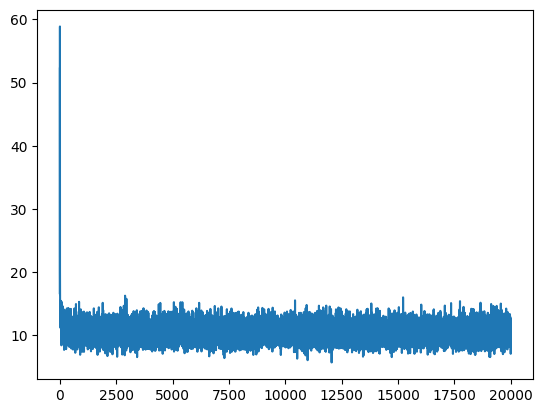

In [28]:
plt.plot(losses)

#### Sampling

In [29]:
X.shape

(5000, 2)

In [30]:
BATCH_SIZE = 256
x_0 = torch.randn(BATCH_SIZE, X.shape[-1]) # Specify the initial condition 

print("x_0 shape:", x_0.shape)

x_0 shape: torch.Size([256, 2])


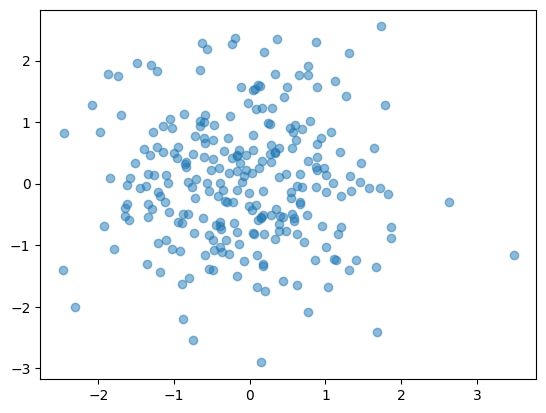

In [31]:
plt.plot(x_0[:, 0].numpy(), x_0[:, 1].numpy(), 'o', alpha=0.5, label='Initial Points')

In [32]:
NUM_STEPS = 100

solver = ODESolver(velocity_model=velocity_model.cpu()) 
# x_1 = solver.sample(x_init=x_0, method='midpoint', step_size=1.0 / NUM_STEPS)

T = torch.linspace(0, 1, 10)
x_1 = solver.sample(time_grid=T, 
                    x_init=x_0, 
                    method='midpoint', 
                    step_size=1.0/NUM_STEPS, 
                    return_intermediates=True)  # sample from the model

print("x_1 shape:", x_1.shape)

x_1 shape: torch.Size([10, 256, 2])


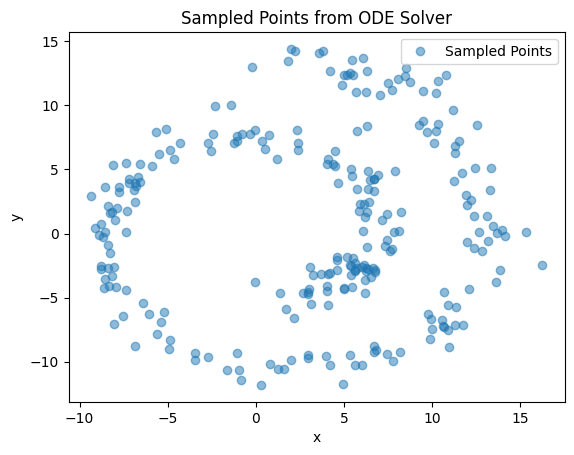

x_1 shape: torch.Size([10, 256, 2])


In [33]:
plt.plot(x_1[-1, :, 0].numpy(), x_1[-1, :, 1].numpy(), 'o', alpha=0.5, label='Sampled Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sampled Points from ODE Solver')
plt.legend()
plt.show()

print("x_1 shape:", x_1.shape)

Samples shape: (10, 256, 2)


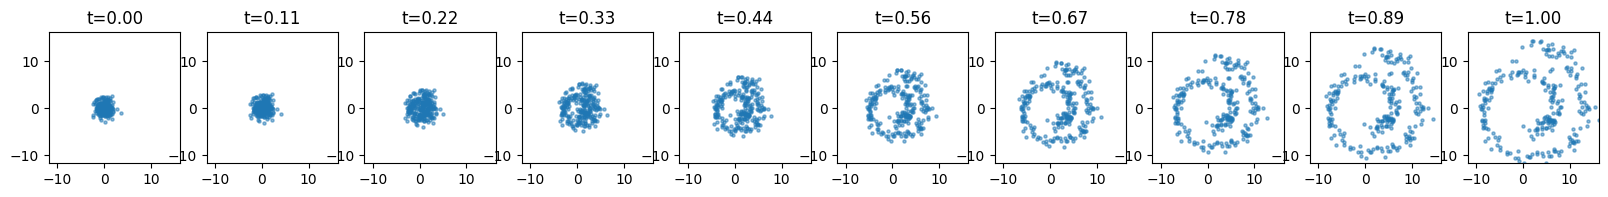

In [34]:
NUM_STEPS = 10
STEP_SIZE = 0.01

solver = ODESolver(velocity_model=velocity_model) 

T = torch.linspace(0, 1, NUM_STEPS) 
sol = solver.sample(
    time_grid=T, 
    x_init=x_0, 
    method='midpoint', 
    step_size=STEP_SIZE, 
    return_intermediates=True,
)  # sample from the model

# - Plot samples
samples = sol.numpy()
print("Samples shape:", samples.shape)

x_min, x_max = samples.min(), samples.max()
_, axs = plt.subplots(1, NUM_STEPS, figsize=(20, 3.2))

for i in range(NUM_STEPS):
    axs[i].scatter(samples[i, :, 0], samples[i, :, 1], s=5, alpha=0.5)
    axs[i].set_title(f"t={T[i].item():.2f}")
    axs[i].set_xlim(x_min, x_max)
    axs[i].set_ylim(x_min, x_max)
    axs[i].set_aspect('equal')

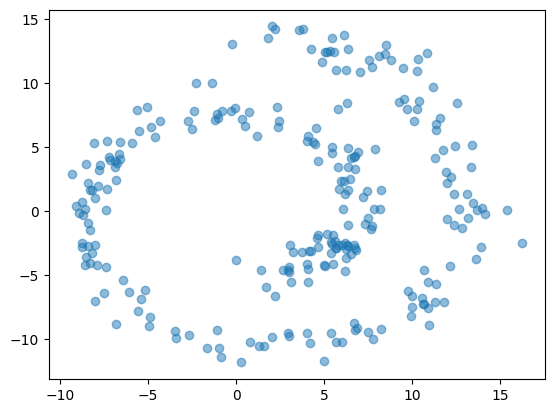

In [35]:
plt.plot(samples[-1, :, 0], samples[-1, :, 1], 'o', alpha=0.5, label='Final Sampled Points')

### Computing Loglikelihood
As per code 3. Refer to 2D flow matching example!

In [36]:
from torch.distributions import Independent, Normal
from matplotlib import cm

In [37]:
print("x_min:", x_min)
print("x_max:", x_max)

x_min: -11.809729
x_max: 16.248869


In [ ]:
data_dim = X.shape[-1]
print("Data dimension:", data_dim)


# sample with likelihood
T = torch.tensor([1., 0.])  # sample times
T = T.to(device=device)


# NOTE:
# Generate a grid of points in the 2D space and compute the likelihood of each point under the model.
# We will visualize this likelihood to understand how well the model captures the data distribution.
# Generates from -16 to 16 in both dimensions, 
# creating a grid of 200x200 points (40,000 total) for likelihood evaluation.
grid_size = 200
x_1 = torch.meshgrid(torch.linspace(-16, 16, grid_size), 
                     torch.linspace(-16, 16, grid_size))
x_1 = torch.stack([x_1[0].flatten(), x_1[1].flatten()], dim=1).to(device)

print("x_1 shape:", x_1.shape)
print(x_1[:10]) 

Data dimension: 2
x_1 shape: torch.Size([40000, 2])
tensor([[-16.0000, -16.0000],
        [-16.0000, -15.8392],
        [-16.0000, -15.6784],
        [-16.0000, -15.5176],
        [-16.0000, -15.3568],
        [-16.0000, -15.1960],
        [-16.0000, -15.0352],
        [-16.0000, -14.8744],
        [-16.0000, -14.7136],
        [-16.0000, -14.5528]], device='cuda:0')


In [45]:
# -- Compute loglikelihood under standard Gaussian
num_steps = 100
batch_size = 256

# gaussian_log_density = Normal(torch.zeros((data_dim,), device=device), torch.ones((data_dim,), device=device)).log_prob

# gaussian_log_density = Normal(
#     torch.zeros(data_dim, device=device), torch.ones(data_dim, device=device)).log_prob

gaussian_log_density = Independent(
    Normal(torch.zeros(2, device=device), torch.ones(2, device=device)), 1).log_prob

# Ensure model and input are on the same device
velocity_model = velocity_model.to(device)
solver = ODESolver(velocity_model=velocity_model)


# compute with exact divergence
x0, exact_log_p = solver.compute_likelihood(
    x_1=x_1,
    method='midpoint',
    step_size=1.0 / num_steps,
    exact_divergence=True,
    log_p0=gaussian_log_density
)


In [54]:
print("x0 shape:", x0.shape)
print("x1 shape:", x_1.shape)
print("Log-likelihood shape:", exact_log_p.shape)

print("x_min:", x_min)
print("x_max:", x_max)

x0 shape: torch.Size([40000, 2])
x1 shape: torch.Size([40000, 2])
Log-likelihood shape: torch.Size([40000])
x_min: -11.809729
x_max: 16.248869


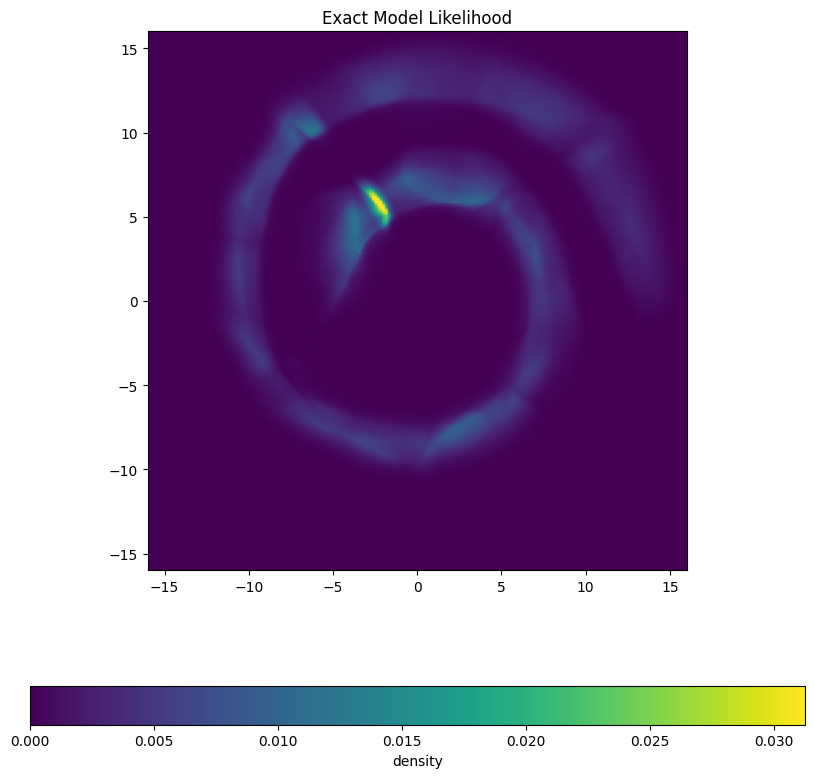

In [49]:
exact_likelihood = torch.exp(exact_log_p).cpu().reshape(grid_size, grid_size).detach().numpy()

cmin = 0.0
cmax = 1/32 # 1/32 is the gt likelihood value
norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)

fig, axs = plt.subplots(1, figsize=(10,10))
axs.imshow(exact_likelihood, extent=(-16, 16, -16, 16), origin='lower', cmap='viridis', norm=norm)
axs.set_title('Exact Model Likelihood')

fig.colorbar(cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs, orientation='horizontal', label='density')
plt.show()